In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 5 — Oral dosing, and the identifiability problem it creates

Most animal PFAS studies use gavage, not IV. The chemical has to be
absorbed before it can be eliminated, so the model gains a compartment
(the gut) and a rate (ka):


```text
C(t) = (F*dose/Vd) * ka/(ka-k) * (exp(-k*t) - exp(-ka*t))
```

Three parameters now -- Vd, k, ka -- plus bioavailability F. This lesson
fits that to real rat data and then shows the two things that go wrong,
both of which are about IDENTIFIABILITY: whether the data can tell the
parameters apart at all.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import plotting as P
from tk import load, oral_1comp, iv_1comp, half_life, clearance

P.setup()

## A. What the curve looks like

In [3]:
dose, Vd, k = 1.0, 0.25, 0.05
print(f"   {'ka (1/d)':>9s} {'Cmax':>8s} {'tmax (d)':>9s} {'AUC':>8s}")
grid = np.linspace(0, 400, 40001)
for ka in [0.05001, 0.2, 1.0, 5.0, 50.0]:
    C = oral_1comp(grid, dose, Vd, k, ka)
    auc = np.trapezoid(C, grid) if hasattr(np, "trapezoid") else np.trapz(C, grid)
    print(f"   {ka:9.2f} {C.max():8.3f} {grid[C.argmax()]:9.2f} {auc:8.2f}")
print(f"   {'IV':>9s} {dose/Vd:8.3f} {0.0:9.2f} "
      f"{dose/clearance(k, Vd):8.2f}")

    ka (1/d)     Cmax  tmax (d)      AUC
        0.05    1.472     20.00    80.00
        0.20    2.520      9.24    80.00
        1.00    3.417      3.15    80.00
        5.00    3.818      0.93    80.00
       50.00    3.972      0.14    80.00
          IV    4.000      0.00    80.00


Faster absorption gives a higher, earlier peak -- but the AUC is
identical for every ka, and equal to the IV value when F = 1. That
follows from CL = F*dose/AUC: total exposure depends on how much got
in and how fast it leaves, never on how fast it entered.

So AUC tells you about CL. The PEAK is what tells you about ka.

## B. Fit a real gavage experiment

In [4]:
rat = load("PFOA_Male_rat")
g = rat[(rat.dataset == "5916078-6.0 mg/kg-gavage") & (rat.conc_mgL > 0)]
g = g.groupby("time_d", as_index=False).conc_mgL.mean()
t, C, DOSE = g.time_d.values, g.conc_mgL.values, 6.0

def oral_log(t, ln_Vd, ln_k, ln_ka):
    return np.log(oral_1comp(t, DOSE, np.exp(ln_Vd), np.exp(ln_k), np.exp(ln_ka)))

popt, pcov = curve_fit(oral_log, t, np.log(C),
                       p0=[np.log(0.25), np.log(0.05), np.log(2.0)], maxfev=20000)
Vd, k, ka = np.exp(popt)
se = np.sqrt(np.diag(pcov))

print("B. PFOA, male rats, 6 mg/kg by gavage (study 5916078)\n")
print(f"   n = {len(t)} time points, day {t.min():g} to {t.max():g}\n")
print(f"   Vd (=V/F)  = {Vd:8.4f} L/kg   (x/ {np.exp(1.96*se[0]):.2f})")
print(f"   k          = {k:8.4f} 1/day  (x/ {np.exp(1.96*se[1]):.2f})")
print(f"   ka         = {ka:8.4f} 1/day  (x/ {np.exp(1.96*se[2]):.2f})")
print(f"   half-life  = {half_life(k):8.2f} days")
print(f"   absorption half-time = {half_life(ka):.3f} days "
      f"({24*half_life(ka):.1f} hours)")

B. PFOA, male rats, 6 mg/kg by gavage (study 5916078)

   n = 10 time points, day 0.0104167 to 50

   Vd (=V/F)  =   0.1593 L/kg   (x/ 1.20)
   k          =   0.0599 1/day  (x/ 1.14)
   ka         =  31.1467 1/day  (x/ 1.64)
   half-life  =    11.57 days
   absorption half-time = 0.022 days (0.5 hours)


## C. Problem 1: F and Vd are the same parameter

In [5]:
print("\nC. You did not measure Vd. You measured Vd/F.\n")
print(f"   {'if F is':>9s} {'then true Vd':>14s} {'then true CL':>14s} {'t1/2':>8s}")
for F in [1.0, 0.8, 0.5, 0.2]:
    print(f"   {F:9.1f} {Vd*F:14.4f} {clearance(k, Vd*F):14.5f} {half_life(k):8.2f}")


C. You did not measure Vd. You measured Vd/F.

     if F is   then true Vd   then true CL     t1/2
         1.0         0.1593        0.00955    11.57
         0.8         0.1275        0.00764    11.57
         0.5         0.0797        0.00477    11.57
         0.2         0.0319        0.00191    11.57


Every oral-only fit has this hole. The curve is identical for
(F=1, Vd=0.25) and (F=0.5, Vd=0.125): only the ratio appears in the
equation. Papers write "Vd/F" and "CL/F" to be honest about it.

Note what is NOT affected: the half-life. k comes from the shape of
the decay, and F just scales the curve. This is the same fact as
lesson 01 section B, and it is why half-life is the most robustly
estimated quantity in all of PK -- and why clearance, which everyone
agrees is the more meaningful parameter, is the harder one.

The fix is an IV arm at the same dose. Study 3749289 and 6302380 both
have one; that is why those studies are valuable.

## D. Problem 2: flip-flop kinetics

In [6]:
lo, hi = sorted([k, ka])
fit_C = oral_1comp(t, DOSE, Vd, lo, hi)                 # k = lo, ka = hi
swap_C = oral_1comp(t, DOSE, Vd * lo / hi, hi, lo)      # k = hi, ka = lo
print(f"   fitted   k = {lo:.4f}, ka = {hi:.4f},  Vd = {Vd:.4f}")
print(f"   swapped  k = {hi:.4f}, ka = {lo:.4f},  Vd = {Vd*lo/hi:.6f}")
print(f"   max |ln| difference between the two curves: "
      f"{np.max(np.abs(np.log(fit_C / swap_C))):.2e}")

   fitted   k = 0.0599, ka = 31.1467,  Vd = 0.1593
   swapped  k = 31.1467, ka = 0.0599,  Vd = 0.000306
   max |ln| difference between the two curves: 0.00e+00


The two curves are IDENTICAL to machine precision. Swapping k and ka
and rescaling Vd by k/ka leaves the prediction untouched -- the
formula is symmetric in the two rates up to that one factor. So oral
data alone cannot tell you which rate is absorption and which is
elimination. This is called
"flip-flop kinetics", and it is not a curiosity: for slowly absorbed
compounds the terminal slope is the ABSORPTION rate, and the
half-life you report is wrong.

Everyone resolves it by assumption -- ka > k, absorption is faster --
which is usually true and occasionally not. The only real resolution
is, again, an IV arm: IV has no ka, so it pins k directly.

## E. Do it properly: fit IV and gavage together

In [7]:
both = rat[rat.study == 6302380]
both = both[(both.dose_mgkg == 1.0) & (both.conc_mgL > 0)]
iv = both[both.route == "iv"].groupby("time_d", as_index=False).conc_mgL.mean()
po = both[both.route == "gavage"].groupby("time_d", as_index=False).conc_mgL.mean()
D = 1.0

def joint(_, ln_Vd, ln_k, ln_ka, logit_F):
    F = 1 / (1 + np.exp(-logit_F))
    Vd_, k_, ka_ = np.exp([ln_Vd, ln_k, ln_ka])
    return np.concatenate([np.log(iv_1comp(iv.time_d.values, D, Vd_, k_)),
                           np.log(oral_1comp(po.time_d.values, D, Vd_, k_, ka_, F))])

y = np.concatenate([np.log(iv.conc_mgL.values), np.log(po.conc_mgL.values)])
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")      # see the note after the table
    p, pc = curve_fit(joint, np.zeros_like(y), y,
                      p0=[np.log(0.25), np.log(0.05), np.log(2.0), 2.0],
                      maxfev=40000)
Vd2, k2, ka2 = np.exp(p[:3]); F2 = 1 / (1 + np.exp(-p[3]))
print(f"   n = {len(iv)} IV + {len(po)} gavage time points, 1 mg/kg each\n")
print(f"   Vd        = {Vd2:8.4f} L/kg      (now a real Vd, not Vd/F)")
print(f"   k         = {k2:8.4f} 1/day")
print(f"   ka        = {ka2:8.4f} 1/day")
print(f"   F         = {F2:8.3f}           (bioavailability, now identified)")
print(f"   half-life = {half_life(k2):8.2f} days")
print(f"   CL        = {clearance(k2, Vd2):8.5f} L/kg/day")

   n = 24 IV + 24 gavage time points, 1 mg/kg each

   Vd        =   0.1229 L/kg      (now a real Vd, not Vd/F)
   k         =   0.1305 1/day
   ka        =  49.0297 1/day
   F         =    1.000           (bioavailability, now identified)
   half-life =     5.31 days
   CL        =  0.01604 L/kg/day


Adding the IV arm removed both problems at once: F is separated from
Vd because the IV curve has F = 1 by definition, and k is pinned by
the IV decay so ka has nowhere to hide.

Two honest caveats on this particular fit. F came out at 1.000,
pressed against its ceiling, so its standard error is undefined --
curve_fit warns about the covariance and we suppressed the warning
only to keep the output readable. That is the right answer
biologically (PFOA is essentially completely absorbed in rats) but
it means the data cannot distinguish F = 1.0 from F = 0.95. And the
half-life here, 5.3 days, is well below the 11.6 days the 6 mg/kg
gavage arm of a different study gave in section B. Different studies,
but also a one-compartment model straining against a two-compartment
curve -- lesson 06.

Design beats statistics. No amount of cleverness in the fitting
recovers information the experiment did not collect.

### F. Figures

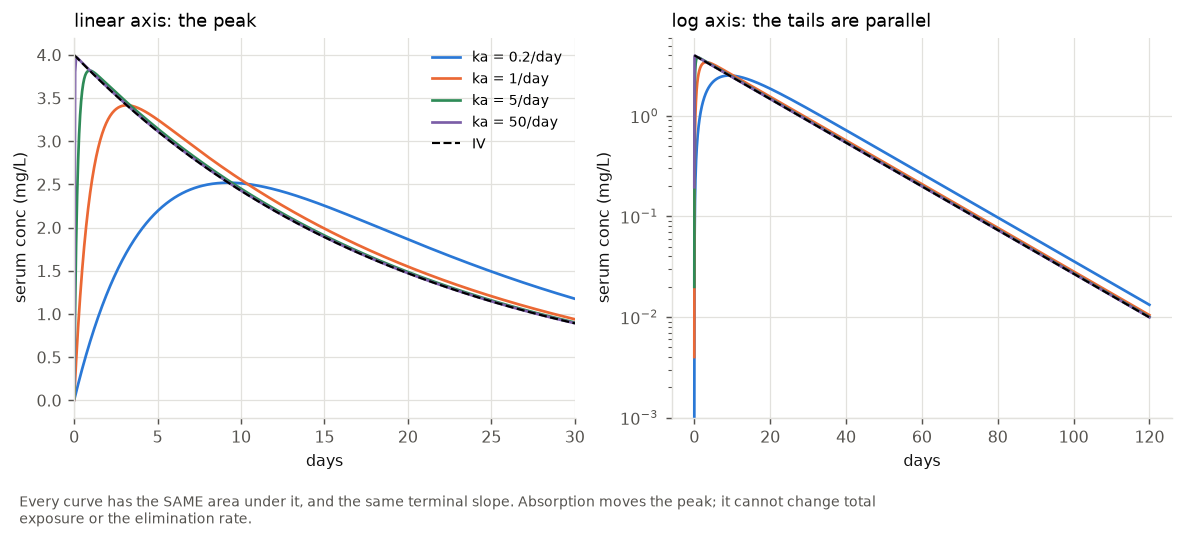

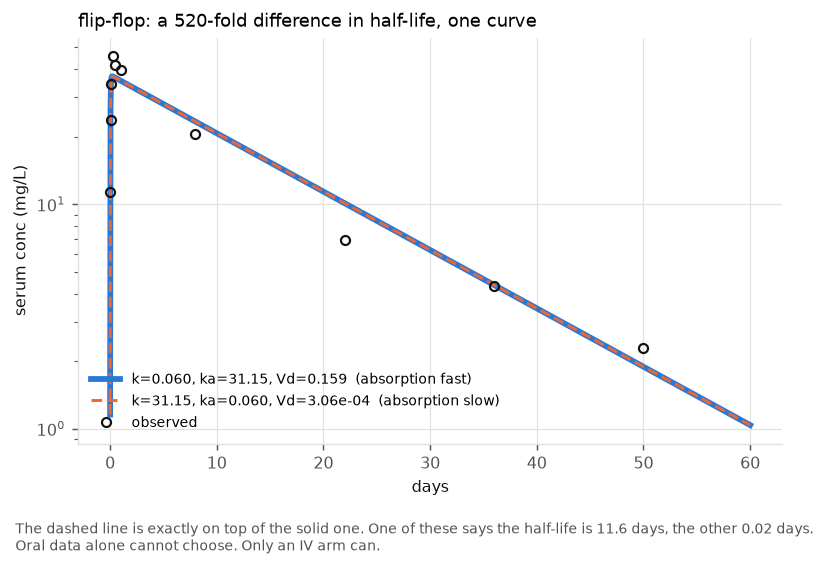

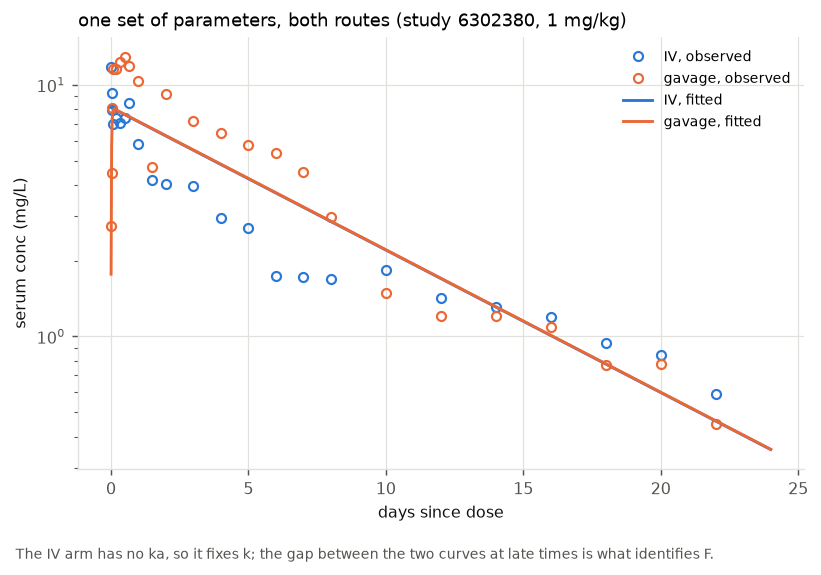

'/home/user/chiu__2022_rerun/tk_learning/figures/05_joint_fit.png'

In [8]:
# F1 -- absorption changes the shape, not the area.
gg = np.linspace(0.001, 120, 2000)
fig, (a, b) = plt.subplots(1, 2, figsize=(9.0, 3.6), constrained_layout=True)
for ka_, col in zip([0.2, 1.0, 5.0, 50.0], P.CYCLE):
    cc = oral_1comp(gg, 1.0, 0.25, 0.05, ka_)
    for ax in (a, b):
        ax.plot(gg, cc, color=col, lw=1.5, label=f"ka = {ka_:g}/day")
for ax, ttl in [(a, "linear axis: the peak"), (b, "log axis: the tails are parallel")]:
    ax.plot(gg, iv_1comp(gg, 1.0, 0.25, 0.05), "k--", lw=1.2, label="IV")
    ax.set(xlabel="days", ylabel="serum conc (mg/L)")
    ax.set_title(ttl)
b.set(yscale="log", ylim=(1e-3, 6))
a.set_xlim(0, 30)
a.legend()
P.save(fig, "05_absorption.png",
       "Every curve has the SAME area under it, and the same terminal "
       "slope. Absorption moves the peak; it cannot change total\n"
       "exposure or the elimination rate.")

# F2 -- flip-flop: two completely different parameter sets, one curve.
fig, ax = plt.subplots(figsize=(6.0, 3.8), constrained_layout=True)
gg2 = np.linspace(0.001, 60, 1500)
ax.plot(gg2, oral_1comp(gg2, DOSE, Vd, lo, hi), "-", color=P.BLUE, lw=3.2,
        label=f"k={lo:.3f}, ka={hi:.2f}, Vd={Vd:.3f}  (absorption fast)")
ax.plot(gg2, oral_1comp(gg2, DOSE, Vd * lo / hi, hi, lo), "--", color=P.ORANGE,
        lw=1.6, label=f"k={hi:.2f}, ka={lo:.3f}, Vd={Vd*lo/hi:.2e}  (absorption slow)")
P.data_points(ax, t, C, label="observed")
ax.set(yscale="log", xlabel="days", ylabel="serum conc (mg/L)")
ax.set_title("flip-flop: a 520-fold difference in half-life, one curve")
ax.legend(loc="lower left")
P.save(fig, "05_flipflop.png",
       "The dashed line is exactly on top of the solid one. One of these "
       "says the half-life is 11.6 days, the other 0.02 days.\n"
       "Oral data alone cannot choose. Only an IV arm can.")

# F3 -- the joint fit that resolves it.
fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
gg3 = np.linspace(0.005, 24, 1200)
P.data_points(ax, iv.time_d, iv.conc_mgL, label="IV, observed", color=P.BLUE)
P.data_points(ax, po.time_d, po.conc_mgL, label="gavage, observed", color=P.ORANGE)
ax.plot(gg3, iv_1comp(gg3, D, Vd2, k2), color=P.BLUE, lw=1.6, label="IV, fitted")
ax.plot(gg3, oral_1comp(gg3, D, Vd2, k2, ka2, F2), color=P.ORANGE, lw=1.6,
        label="gavage, fitted")
ax.set(yscale="log", xlabel="days since dose", ylabel="serum conc (mg/L)")
ax.set_title("one set of parameters, both routes (study 6302380, 1 mg/kg)")
ax.legend()
P.save(fig, "05_joint_fit.png",
       "The IV arm has no ka, so it fixes k; the gap between the two "
       "curves at late times is what identifies F.")

### Questions

1. In section A, why is tmax later when ka is smaller? Write down dC/dt = 0 and solve for t.
1. Section C: if a paper reports "CL/F = 0.02 L/kg/day" and you assume F = 1 when the truth is F = 0.6, is the real clearance higher or lower than reported? What about the half-life?
1. In section D the swap needed Vd rescaled by k/ka. Work through the algebra: why exactly that factor, and why does the apparent sign change in ka/(ka-k) cancel out?
1. PFOA is almost completely absorbed in rats (F near 1). Does that make the section C problem go away, or just make the assumption a good one? What is the difference?

### Exercises

1. Refit section B forcing ka = 100 (essentially instant absorption). How much worse is the fit? How much does the half-life move?
1. Run section E on study 3749289, which also has matched IV and gavage arms at 1 mg/kg. Do the two studies agree on F?
1. The half-life from section B is a single number with a confidence interval that assumes the model is right. Compare it to the terminal-slope answer for the same dataset in lesson 03 section C.